     height_cm  density_g_cm3  drho_dh_g_cm3_per_cm
0     0.000000       0.001230          0.000000e+00
1  1100.110011       0.001228         -1.235629e-09
2  2200.220022       0.001227         -1.234263e-09
3  3300.330033       0.001226         -1.232898e-09
4  4400.440044       0.001224         -1.231534e-09
10000


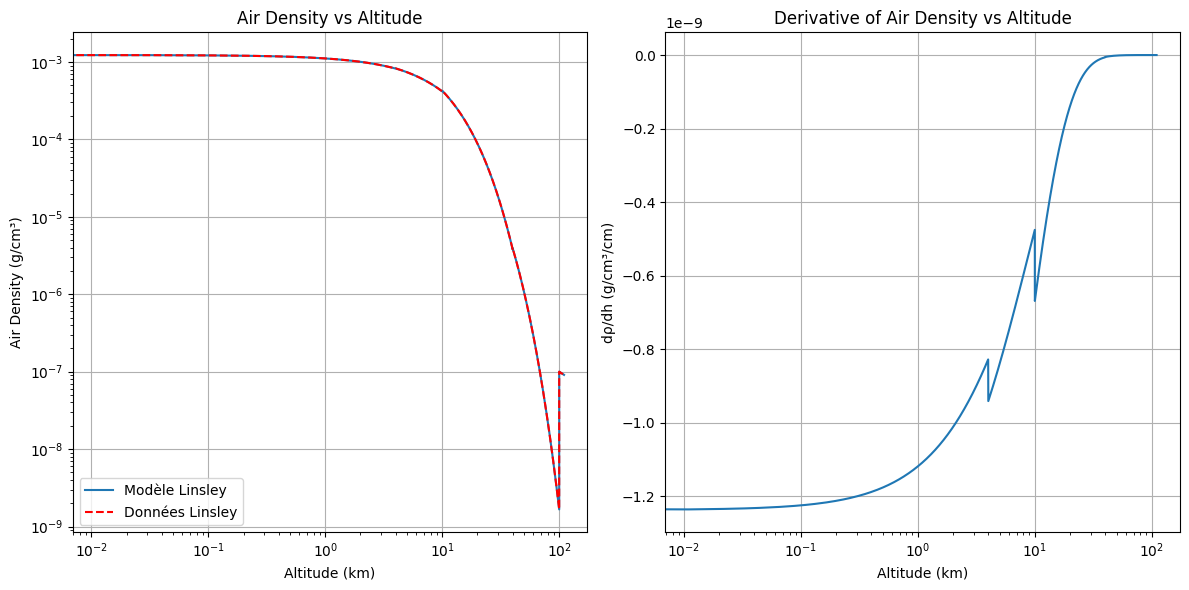

     height_cm  density_g_cm3  drho_dh_g_cm3_per_cm
0     0.000000       0.001230          0.000000e+00
1  1100.110011       0.001228         -1.235629e-09
2  2200.220022       0.001227         -1.234263e-09
3  3300.330033       0.001226         -1.232898e-09
4  4400.440044       0.001224         -1.231534e-09


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

linsey = pd.read_parquet('linsley_atmosphere.parquet')
print(linsey.head())
print(len(linsey))

# Coefficients Linsley (ci en m dans le tableau original)
layers = [
    (1,   0.0,        4.0,   -186.5562,  1222.6562,  9941.8638),
    (2,   4.0,       10.0,    -94.9199,  1144.9069,  8781.5355),
    (3,  10.0,       40.0,      0.61289, 1305.5948,  6361.4304),
    (4,  40.0,      100.0,      0.0,      540.1778,  7721.7016),
    (5, 100.0,      113.0,     0.01128292,   1.0,   1e7),
]

# bornes en cm (les hi sont en km -> *1e5)
h_bounds_cm = np.array([[l[1] * 1e5, l[2] * 1e5] for l in layers])

def rho_air(h_cm: float) -> float:
    """
    Densité de l'air en g/cm^3 pour une altitude h en cm.
    """
    h = float(h_cm)
    idx = None
    for k, (hmin, hmax) in enumerate(h_bounds_cm):
        if hmin <= h < hmax:
            idx = k
            break
    if idx is None:
        return 0.0

    i, _, _, ai, bi, ci_m = layers[idx]
    ci_cm = ci_m * 100.0  # conversion m -> cm

    if i < 5:
        rho = (bi / ci_cm) * np.exp(-h / ci_cm)
    else:
        rho = bi / h

    return rho  # g/cm^3


def drho_dh(h_cm: float) -> float:
    """
    Dérivée dρ/dh en g/cm^3 par cm, pour une altitude h en cm.
    """
    h = float(h_cm)
    idx = None
    for k, (hmin, hmax) in enumerate(h_bounds_cm):
        if hmin <= h < hmax:
            idx = k
            break
    if idx is None or h == 0.0:
        return 0.0

    i, _, _, ai, bi, ci_m = layers[idx]
    ci_cm = ci_m * 100.0

    if i < 5:
        drho = -(bi / ci_cm**2) * np.exp(-h / ci_cm)
    else:
        drho = -bi / (h**2)

    return drho  # g/cm^3 / cm


# x en cm, de 0.1 km à 110 km
x_cm = np.linspace(0, (110 * 1e5), 10000)

rho_values = np.array([rho_air(h) for h in x_cm])
rho_derivative_values = np.array([drho_dh(h) for h in x_cm])

dataframe = pd.DataFrame({
    'height_cm': x_cm,
    'density_g_cm3': rho_values,
    'drho_dh_g_cm3_per_cm': rho_derivative_values
})
dataframe.to_parquet('linsley_atmosphere.parquet', index=False)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(x_cm / 1e5, rho_values, label='Modèle Linsley')
plt.plot(linsey['height_cm'] / 1e5, linsey['density_g_cm3'], c='r', linestyle='dashed', label='Données Linsley')
plt.xscale('log')
plt.yscale('log')
# plt.xlim(3.9, 4.1)
plt.xlabel('Altitude (km)')
plt.ylabel('Air Density (g/cm³)')
plt.title('Air Density vs Altitude')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_cm / 1e5, rho_derivative_values)
plt.xscale('log')
plt.xlabel('Altitude (km)')
plt.ylabel('dρ/dh (g/cm³/cm)')
plt.title('Derivative of Air Density vs Altitude')
plt.grid()

plt.tight_layout()
plt.show()


print(dataframe.head())